In [1]:
import ee, pandas as pd, numpy as np, matplotlib.pyplot as plt
ee.Initialize(project="sentinel-487715")

# Ghana boundary
ghana = ee.FeatureCollection("USDOS/LSIB_SIMPLE/2017") \
    .filter(ee.Filter.eq("country_na", "Ghana")) \
    .geometry()

# Roads asset
roads = ee.FeatureCollection("projects/sentinel-487715/assets/ghana_roads")


In [2]:
# Annual composite (2023)
s2 = (ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
      .filterBounds(ghana)
      .filterDate("2023-01-01", "2023-12-31")
      .filter(ee.Filter.lt("CLOUDY_PIXEL_PERCENTAGE", 20))
      .select(["B2","B3","B4","B8","B11","B12"])
      .median())

# Indices
ndvi = s2.normalizedDifference(["B8","B4"]).rename("NDVI")
ndmi = s2.normalizedDifference(["B8","B11"]).rename("NDMI")
ndbi = s2.normalizedDifference(["B11","B8"]).rename("NDBI")
ndwi = s2.normalizedDifference(["B3","B8"]).rename("NDWI")
bsi = (s2.select("B11").add(s2.select("B4"))
       .subtract(s2.select("B8").add(s2.select("B2")))
       .divide(s2.select("B11").add(s2.select("B4"))
               .add(s2.select("B8")).add(s2.select("B2")))
       .rename("BSI"))

img = s2.addBands([ndvi, ndmi, ndbi, ndwi, bsi])


In [3]:
# Sample equal numbers per class for fast analysis
classes = ["residential","tertiary","secondary","primary","unclassified","trunk"]
N = 50

def sample_class(fc, cls, n):
    return (fc.filter(ee.Filter.eq("fclass", cls))
              .randomColumn("rand")
              .sort("rand")
              .limit(n))

sample_roads = ee.FeatureCollection([])
for cls in classes:
    sample_roads = sample_roads.merge(sample_class(roads, cls, N))

# Use centroids (fast)
sample_pts = sample_roads.map(lambda f: f.setGeometry(f.geometry().centroid()))

# Sample Sentinel values at centroids
sampled = img.sampleRegions(
    collection=sample_pts,
    scale=30,
    geometries=False
)

info = sampled.getInfo()
rows = [f["properties"] for f in info["features"]]
df = pd.DataFrame(rows)
df.head()


,B11,B12,B2,B3,B4,B8,BSI,NDBI,NDMI,NDVI,...,code,fclass,layer,maxspeed,name,oneway,osm_id,rand,ref,tunnel
0,3250.0,3032.5,961.0,1284.5,1712.5,2332.0,0.202229,0.164457,-0.164457,0.153171,...,5122,residential,0,0,,B,634473017,0.000013,,F
1,3068.5,2586.5,828.5,1129.0,1376.0,2372.5,0.162645,0.127918,-0.127918,0.265840,...,5122,residential,0,0,,B,621012103,0.000014,,F
2,3160.0,2423.0,1052.0,1272.0,1422.0,2758.0,0.091992,0.067928,-0.067928,0.319617,...,5122,residential,0,0,,B,1285454129,0.000029,,F
3,3470.0,2819.0,669.0,968.0,1469.0,2557.0,0.209798,0.151485,-0.151485,0.270243,...,5122,residential,0,0,,B,768317820,0.000034,,F
4,3390.0,3007.0,941.0,1256.0,1677.0,2307.0,0.218761,0.190100,-0.190100,0.158133,...,5122,residential,0,0,,B,1071012772,0.000036,,F


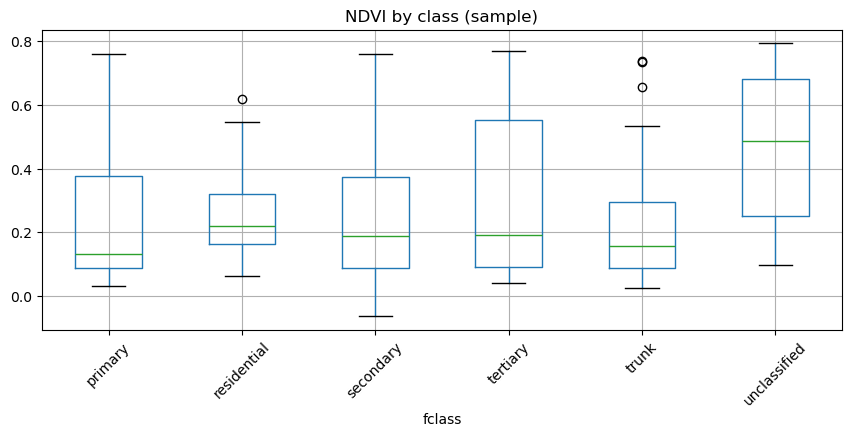

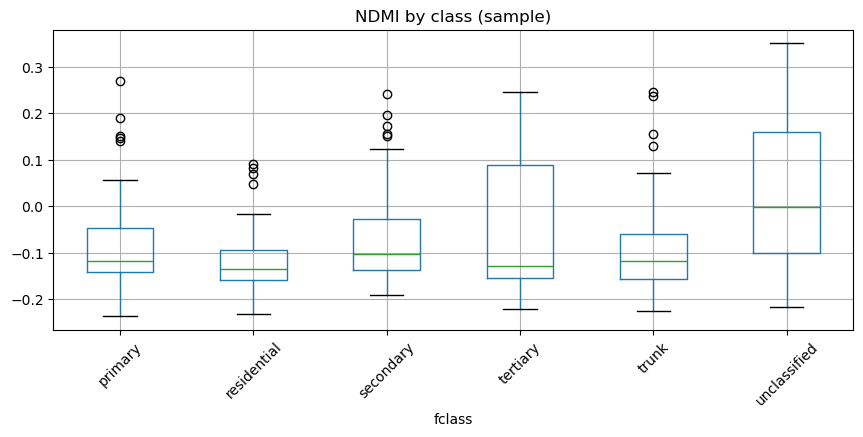

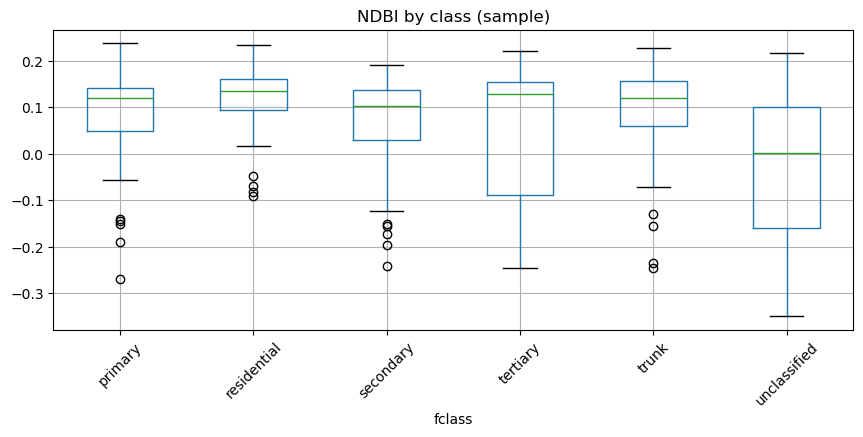

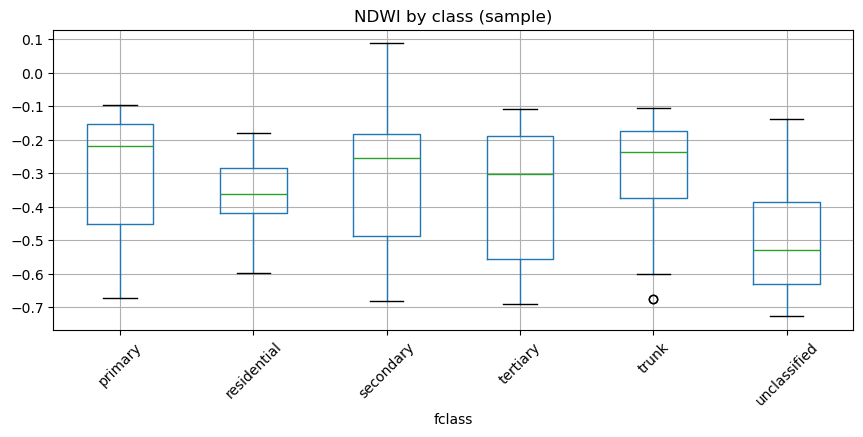

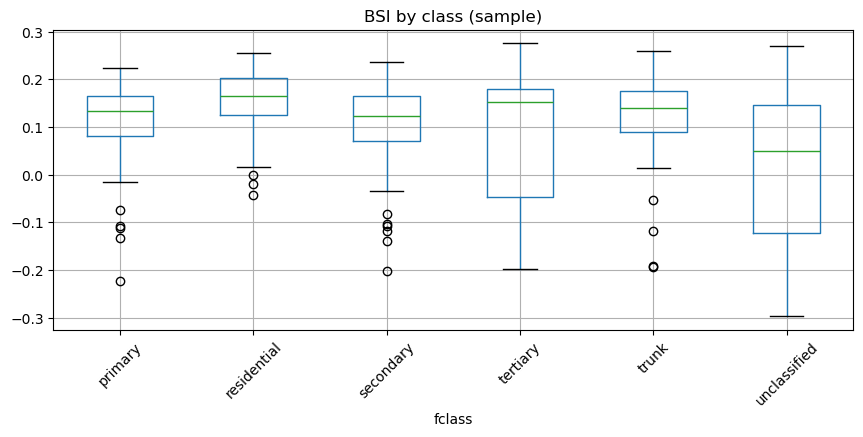

In [4]:
# Compare spectral proxies by class
for feat in ["NDVI","NDMI","NDBI","NDWI","BSI"]:
    df.boxplot(column=feat, by="fclass", figsize=(10,4), rot=45)
    plt.title(f"{feat} by class (sample)")
    plt.suptitle("")
    plt.show()


In [5]:
# Build quarterly composites and extract NDVI/NDMI for the same sample points
quarters = {
    "Q1": ("2023-01-01","2023-03-31"),
    "Q2": ("2023-04-01","2023-06-30"),
    "Q3": ("2023-07-01","2023-09-30"),
    "Q4": ("2023-10-01","2023-12-31"),
}

def quarter_img(start, end):
    s2q = (ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
           .filterBounds(ghana)
           .filterDate(start, end)
           .filter(ee.Filter.lt("CLOUDY_PIXEL_PERCENTAGE", 20))
           .select(["B4","B8","B11"])
           .median())
    ndvi = s2q.normalizedDifference(["B8","B4"]).rename("NDVI")
    ndmi = s2q.normalizedDifference(["B8","B11"]).rename("NDMI")
    return s2q.addBands([ndvi, ndmi])

quarter_vals = []
for q, (start,end) in quarters.items():
    qimg = quarter_img(start, end)
    qsample = qimg.sampleRegions(sample_pts, scale=30, geometries=False).getInfo()
    qrows = [f["properties"] for f in qsample["features"]]
    qdf = pd.DataFrame(qrows)
    qdf["quarter"] = q
    quarter_vals.append(qdf)

qdf_all = pd.concat(quarter_vals, ignore_index=True)

# variability per road class
q_stats = qdf_all.groupby(["fclass","quarter"])[["NDVI","NDMI"]].mean().reset_index()
q_stats.head()


,fclass,quarter,NDVI,NDMI
0,primary,Q1,0.192980,-0.096305
1,primary,Q2,0.210364,-0.042049
2,primary,Q3,0.378773,0.282133
3,primary,Q4,0.255766,-0.063137
4,residential,Q1,0.221611,-0.136032


In [6]:
# Compare 10m vs 100m buffers around the same sample
def buffer_roads(fc, dist):
    return fc.map(lambda f: f.setGeometry(f.geometry().buffer(dist)))

buf10 = buffer_roads(sample_roads, 10)
buf100 = buffer_roads(sample_roads, 100)

def reduce_buffers(fc):
    return img.reduceRegions(
        collection=fc,
        reducer=ee.Reducer.mean().forEachBand(img),
        scale=30,
        tileScale=8
    )

buf10_fc = reduce_buffers(buf10).limit(300).getInfo()
buf100_fc = reduce_buffers(buf100).limit(300).getInfo()

df10 = pd.DataFrame([f["properties"] for f in buf10_fc["features"]])
df100 = pd.DataFrame([f["properties"] for f in buf100_fc["features"]])

df10["buffer"] = "10m"
df100["buffer"] = "100m"

df_ctx = pd.concat([df10, df100], ignore_index=True)

# Example comparison
df_ctx.boxplot(column="BSI", by="buffer", figsize=(6,4))
plt.title("BSI: Road buffer vs Neighborhood buffer")
plt.suptitle("")
plt.show()


EEException: Computation timed out.

In [7]:
from scipy.stats import kruskal

# Example on NDVI
groups = [df[df["fclass"]==cls]["NDVI"].dropna() for cls in classes]
stat, p = kruskal(*groups)
print("Kruskal NDVI stat:", stat, "p:", p)


Kruskal NDVI stat: 45.100336932707606 p: 1.384301733708316e-08


In [8]:
# Define a simple hotspot rule: high BSI + low NDVI
df["hotspot"] = (df["BSI"] > df["BSI"].quantile(0.75)) & (df["NDVI"] < df["NDVI"].quantile(0.25))

# Count hotspots by class
df.groupby("fclass")["hotspot"].mean().sort_values(ascending=False)


fclass
tertiary        0.12
trunk           0.10
primary         0.06
residential     0.06
secondary       0.06
unclassified    0.02
Name: hotspot, dtype: float64

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

features = ["NDVI","NDMI","NDBI","NDWI","BSI","B2","B3","B4","B8","B11","B12"]
X = df[features].fillna(0)
y = df["fclass"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)
model = RandomForestClassifier(n_estimators=200, random_state=0)
model.fit(X_train, y_train)

pred = model.predict(X_test)
print(classification_report(y_test, pred))


              precision    recall  f1-score   support

     primary       0.39      0.50      0.44        14
 residential       0.31      0.62      0.41        13
   secondary       0.25      0.20      0.22        15
    tertiary       0.13      0.14      0.14        14
       trunk       0.40      0.29      0.33        14
unclassified       0.44      0.20      0.28        20

    accuracy                           0.31        90
   macro avg       0.32      0.32      0.30        90
weighted avg       0.33      0.31      0.30        90

